In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('titanic.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Categorical Datasets

## Find the categorical dataset

In [3]:
categorical=[]

for col in df.columns:
   if df[col].dtype == 'O':
    categorical.append(col)
print('Categorical Dataset',categorical)

Categorical Dataset ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


In [4]:
cat_data = df[categorical]
cat_data.head()

,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no


In [5]:
categorical=[col for col in df.columns if df[col].dtype=='O']
cat_data=df[categorical]
cat_data.head()

,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


# Understand the categorical dataset by data visulization

## CountPlot Function using sns



### Using bar graph
### df['column name'].value_counts().plot(kind='bar')

<Axes: xlabel='survived'>

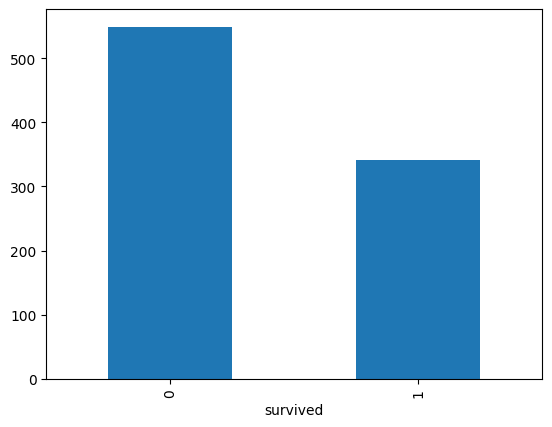

In [7]:
import seaborn as sns
# sns.countplot(df['survived'])
df['survived'].value_counts().plot(kind='bar')

### Using CountPlot
### 1. sns.countplot(x=df['column name'])
### 2. sns.countplot(x='column name', data=df)

<Axes: xlabel='survived', ylabel='count'>

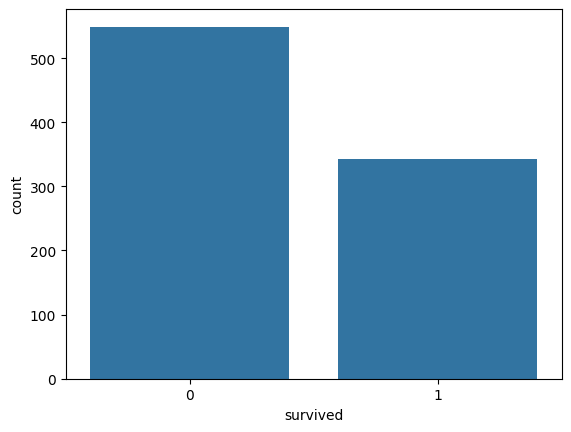

In [8]:
sns.countplot(x=df['survived'])

In [9]:
df['class'].value_counts()

,count
class,
Third,491
First,216
Second,184


### Using Countplot with multiple color
### sns.countplot(x='column name' , data=df , hue='column name' , palette={'Value1':'Color1, 'Value2':'Color2'.......})

<Axes: xlabel='class', ylabel='count'>

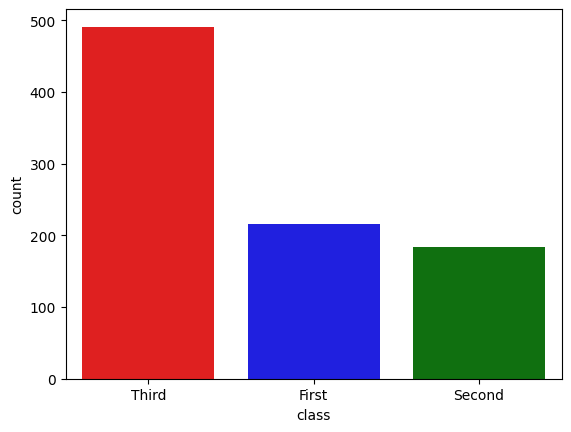

In [10]:
sns.countplot(x='class', data=df, hue='class', palette={'Third':'red', 'Second':'green' , 'First':'blue'}, legend=False)

## PieChart


### df['column name'].value_counts().plot(kind='pie' , autopct='.%.2f')

<Axes: ylabel='count'>

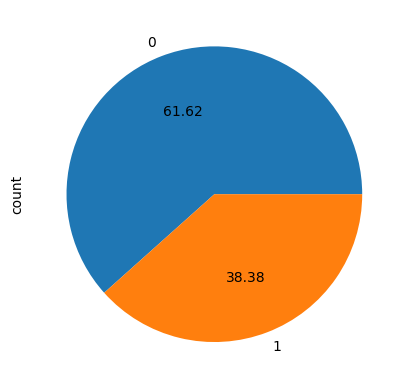

In [11]:
df['survived'].value_counts().plot(kind='pie' , autopct='%.2f')

<Axes: ylabel='count'>

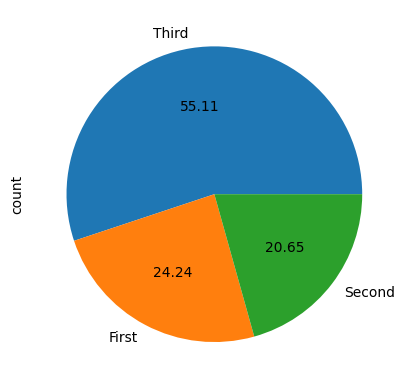

In [12]:
df['class'].value_counts().plot(kind='pie' , autopct='%.2f')

# Numerical Dataset

## Find the Numerical dataset

In [13]:
numerical=[]

for col in df.columns:
   if df[col].dtype != 'O':
    numerical.append(col)
print('Numerical Dataset',numerical)

Numerical Dataset ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone']


In [14]:
num_data=df[numerical]
num_data.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
0,0,3,22.0,1,0,7.2500,True,False
1,1,1,38.0,1,0,71.2833,False,False
2,1,3,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,False
4,0,3,35.0,0,0,8.0500,True,True


# Understand the numerical dataset by data visulization

## Histogram


### Uses:
- Used to show the frequency distribution of numerical data.
- Helps understand data spread and skewness.
- Used to detect distribution patterns.
- plt.hist(df['column name'] , bins=number of bar ,color='color' , edgecolor='color')

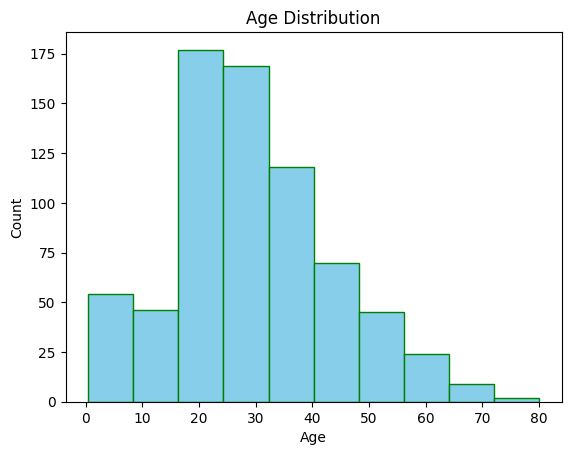

In [20]:
import matplotlib.pyplot as plt

# plt.hist(df[column name] , bins= number of bar you want , color='name of the color' , edgecolor='Black')
plt.hist(df['age'] , bins=10 ,color='skyblue' , edgecolor='green')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Displot

### Uses:
- Used to show histogram + density curve (KDE).
- Helps understand probability distribution.
- Useful for checking normal distribution.
- sns.histplot(df['column name'] , kde=True)

<Axes: xlabel='age', ylabel='Count'>

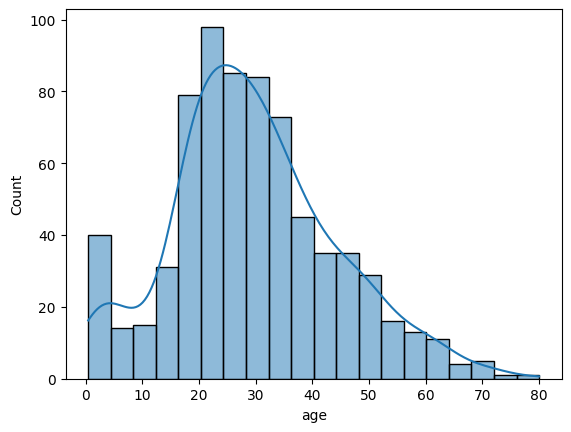

In [31]:
sns.histplot(df['age'], kde=True)

## Boxplot

### Uses:
- Used to detect outliers.
- Shows Q1, Median (Q2), and Q3.
- Helps understand spread and skewness of data.
- sns.boxplot(x=num_data[col] , color='color')

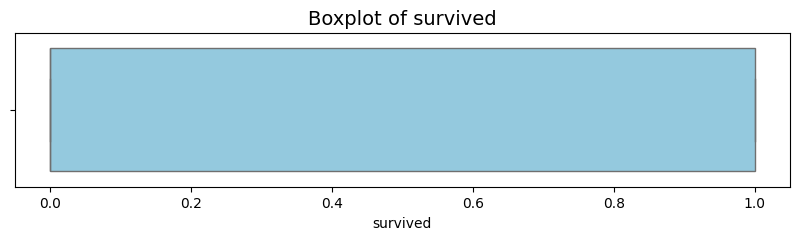

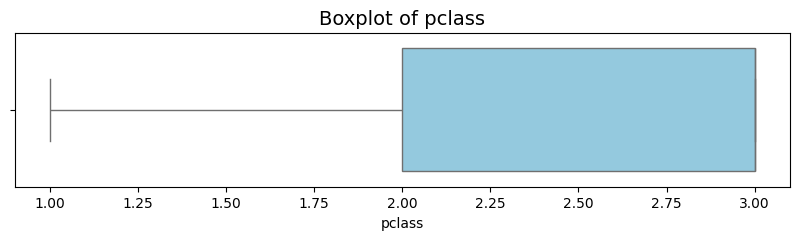

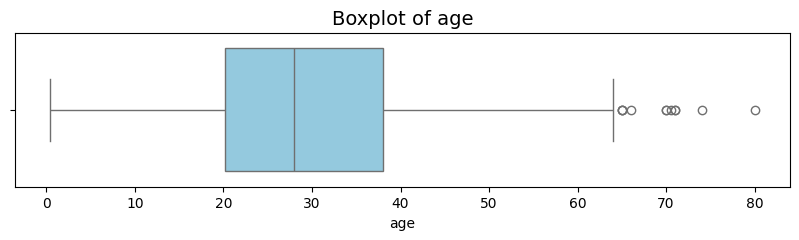

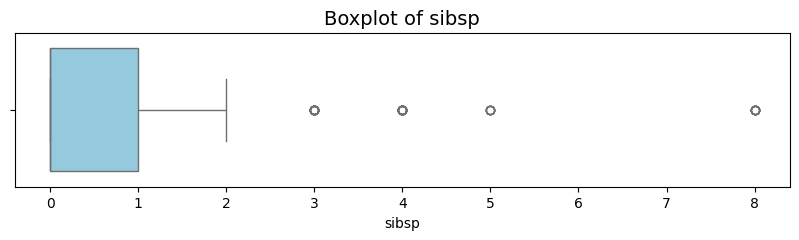

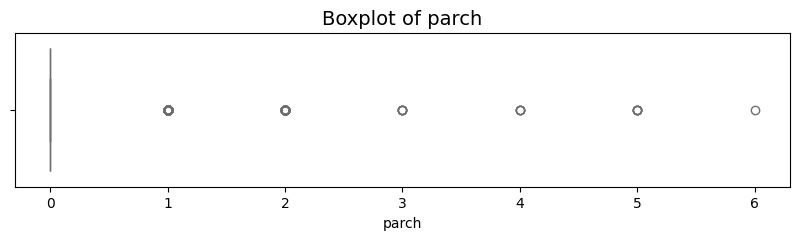

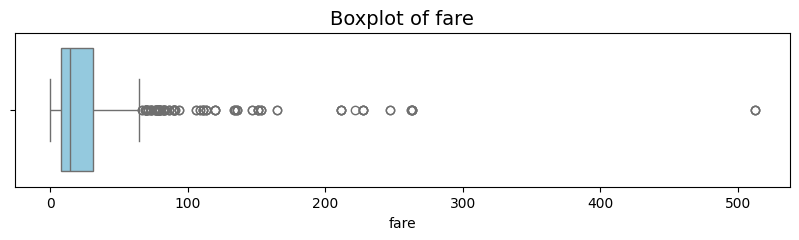

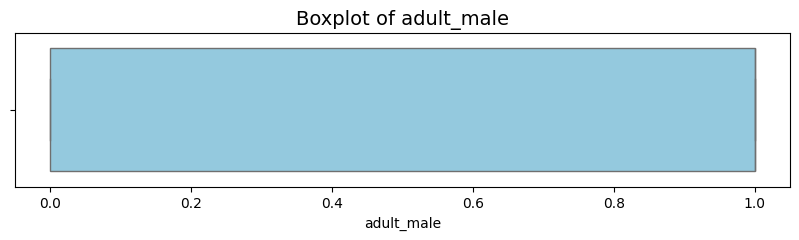

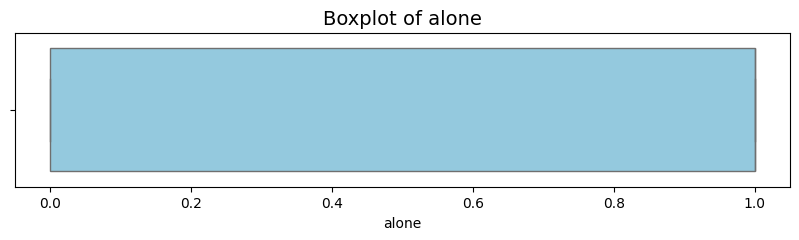

In [38]:
# Numerical columns only
num_cols=num_data.columns
for col in num_cols:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=num_data[col].dropna(),
        color='skyblue'
    )

    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.xlabel(col)

    plt.show()